# Data as Tensors — Practice Notebook

Practice turning different types of real-world data into tensors suitable for training a neural network: tabular data, images, time series, and text. All datasets are small, real, and already saved under `data/external/` (see `notebooks/README` or the task cells below for the exact source). The focus is not on training a model, but on understanding how data becomes tensors of the right shape, dtype, and scale.

In [324]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

In [325]:
%matplotlib inline

pd.set_option("display.width", 175)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

## Task 1. Tabular data as tensors

Use the real [Titanic dataset](data/external/titanic.csv) (891 passengers: `survived`, `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, ...). We'll treat `age` and `fare` as numeric features, `sex` and `embarked` as categorical features, and `survived` as the target.

**Do the following:**
- load the CSV and select the columns above; fill the missing `age`/`embarked` values (real data has gaps)
- normalize the numeric features (`age`, `fare`)
- encode the categorical features (`sex`, `embarked`) via one-hot or integer encoding
- build `X_numeric`, `X_categorical`, the combined `X`, and the target tensor `y`
- print the shape and dtype of `X_numeric`, `X_categorical`, `X`, and `y`

**Additionally**, split the data into train/validation sets and check that the number of features matches between the two splits and that no target values leaked into `X`.

In [326]:
df = pd.read_csv("../data/test/titanic.csv")

df = df.drop(columns=["alive"])

In [327]:
df["age_NaN"] = df["age"].isna()
df["age"] = df["age"].fillna(-1)

for col in ["age", "fare"]:
    df[col] = df[col].astype(float)
    df[col] = (df[col] - df[col].mean()) / df[col].std()

In [328]:
for col in ["embarked", "deck", "embark_town"]:
    df[col] = df[col].fillna("NaN")

df = pd.get_dummies(
    df,
    columns=[
        "sex",
        "sibsp",
        "pclass",
        "parch",
        "embarked",
        "class",
        "who",
        "deck",
        "embark_town",
    ],
    dtype=float,
)

In [329]:
for col in df.columns:
    df[col] = df[col].astype(float)

df

,survived,age,fare,adult_male,alone,age_NaN,sex_female,sex_male,sibsp_0,sibsp_1,sibsp_2,sibsp_3,sibsp_4,sibsp_5,sibsp_8,pclass_1,pclass_2,pclass_3,parch_0,parch_1,parch_2,parch_3,parch_4,parch_5,parch_6,embarked_C,embarked_NaN,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_child,who_man,who_woman,deck_A,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_NaN,embark_town_Cherbourg,embark_town_NaN,embark_town_Queenstown,embark_town_Southampton
0,0.0,-0.089584,-0.502163,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.805897,0.786404,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.134286,-0.488580,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.637994,0.420494,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.637994,-0.486064,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,0.190254,-0.386454,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
887,1.0,-0.257487,-0.044356,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
888,0.0,-1.376838,-0.176164,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
889,1.0,0.134286,-0.044356,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [330]:
cat_cols = [col for col in df.columns if col not in ["survived", "age", "fare"]]

X_numeric = torch.from_numpy(df.loc[:, ["age", "fare"]].to_numpy())
X_categorical = torch.from_numpy(df.loc[:, cat_cols].to_numpy())

X = torch.from_numpy(df.loc[:, df.columns != "survived"].to_numpy())
y = torch.from_numpy(df.loc[:, "survived"].to_numpy())

print("X_numeric:", X_numeric.shape, X_numeric.dtype)
print("X_categorical:", X_categorical.shape, X_categorical.dtype)
print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

X_numeric: torch.Size([891, 2]) torch.float64
X_categorical: torch.Size([891, 44]) torch.float64
X: torch.Size([891, 46]) torch.float64
y: torch.Size([891]) torch.float64


## Task 2. Images as tensors

Use the real sample photos in `data/external/images/` (`china.jpg`, `flower.jpg`) plus `data/test/test_image.png`, resized to `64 × 64`.

**Do the following:**
- load each image, get its tensor, check shape, dtype, and pixel value range
- scale pixel values to `[0, 1]`
- permute the axes from `H × W × C` to `C × H × W`
- stack the images into a batch of shape `[B, 3, 64, 64]`
- extract the red, green, and blue channel tensors
- build a grayscale version and a flattened version of an image

**Additionally**, compute the per-channel mean and std over the whole batch and explain why this matters for normalization.

In [331]:
batch_size = 2
batch = torch.zeros(batch_size, 3, 64, 64, dtype=torch.uint8)

In [332]:
folder = Path("../data/test/images")
images = list(folder.iterdir())

In [333]:
for i in range(batch_size):
    img = Image.open(images[i]).convert("RGB")
    img = img.resize((64, 64))

    img_arr = np.array(img)
    img_t = torch.from_numpy(img_arr)
    img_t = img_t.permute(2, 0, 1)
    img_t = img_t[:3]
    batch[i] = img_t

In [334]:
image = batch[0]

image_r = image[0].unsqueeze(0)
image_g = image[1].unsqueeze(0)
image_b = image[2].unsqueeze(0)

image_gray = image.sum(dim=0, keepdim=True) // 3

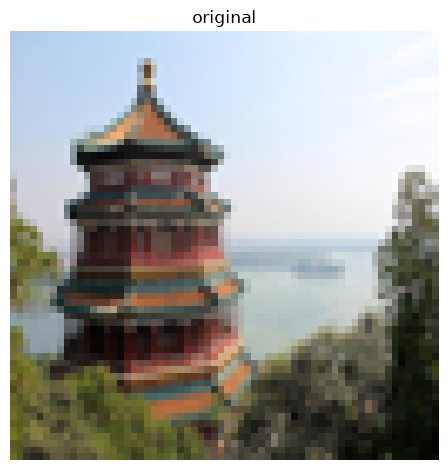

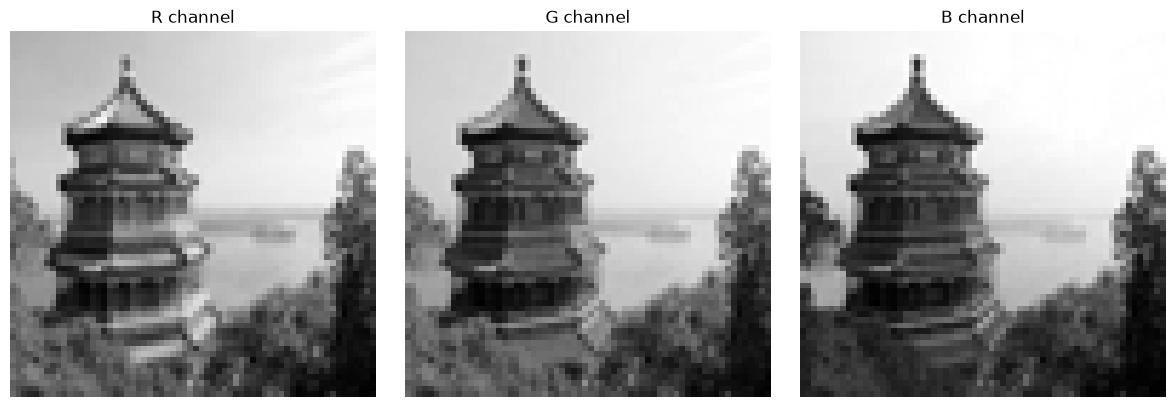

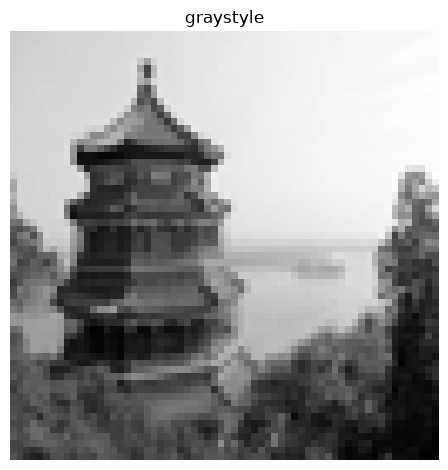

In [335]:
plt.imshow(image.permute(1, 2, 0))
plt.title("original")
plt.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

channels = [image_r, image_g, image_b]
titles = ["R channel", "G channel", "B channel"]

for ax, channel, title in zip(axes, channels, titles, strict=False):
    ax.imshow(channel[0], cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.imshow(image_gray[0], cmap="gray")
plt.title("graystyle")
plt.axis("off")
plt.tight_layout()
plt.show()

## Task 3. Time series as tensors

Use the real [Bike Sharing Demand dataset](data/external/bike_sharing_demand.csv) (500 hourly records: `temp`, `feel_temp`, `humidity`, `windspeed`, `count`, ...).

**Do the following:**
- turn `temp`, `humidity`, `windspeed`, and `count` into sliding windows of length 7 hours: `X` of shape `[num_windows, 7, num_features]` and `y` with the next-hour `count`
- split into train/validation by time (validation must come after train, no shuffling)
- normalize using statistics computed only on the train part

**Additionally**, build both a many-to-one version (predict a single next value) and a many-to-many version (predict the next 7 values), and compare the shape of `y` in each case.

In [336]:
df = pd.read_csv("../data/test/bike_sharing_demand.csv")

feature_cols = ["temp", "humidity", "windspeed", "count"]

features = torch.from_numpy(df.loc[:, feature_cols].to_numpy()).float()

target = torch.from_numpy(df.loc[:, "count"].to_numpy()).float()

X = features[:-1].unfold(dimension=0, size=7, step=1)
X = X.permute(0, 2, 1).contiguous()

y = target[7:]

print("X:", X.shape)
print("y:", y.shape)

X: torch.Size([493, 7, 4])
y: torch.Size([493])


In [337]:
split_idx = int(0.8 * X.shape[0])

X_train, y_train = X[:split_idx], y[:split_idx]
X_val, y_val = X[split_idx:], y[split_idx:]

In [338]:
train_mean = X_train.mean()
train_std = X_train.std()

X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std

## Task 4. Text as tensors

Use the real sentences in `data/external/newsgroup_sentences.txt` (short excerpts from the 20 Newsgroups dataset).

**Do the following:**
- tokenize the sentences and build a `token → id` vocabulary, including special tokens `<PAD>`, `<UNK>`, `<BOS>`, `<EOS>`
- encode each sentence as a list of ids, pad them to the same length, and build an `attention_mask`
- produce `input_ids` and `attention_mask` tensors of shape `[batch_size, max_seq_len]`

**Additionally**, build a one-hot representation of shape `[batch_size, max_seq_len, vocab_size]` and compare it with the integer id representation.

In [339]:
with Path("../data/test/newsgroup_sentences.txt").open() as f:
    text = f.read()

lines = text.split("\n")[:-1]

In [340]:
token2id = {
    "<PAD>": 0,
    "<UNK>": 1,
    "<BOS>": 2,
    "<EOS>": 3,
}
last_id = 3

for line in lines:
    for token in re.findall(r"\w+", line.lower()):
        if token not in token2id:
            last_id += 1
            token2id[token] = last_id

id2token = {id: token for token, id in token2id.items()}

print(token2id)
print(id2token)

{'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3, 'i': 4, 'just': 5, 'got': 6, 'out': 7, 'of': 8, 'the': 9, 'army': 10, 'preliminary': 11, 'analysis': 12, 'indicates': 13, 'data': 14, 'was': 15, 'received': 16, 'properly': 17, 'thruster': 18, 'performance': 19, 'throughout': 20, 'activity': 21, 'nominal': 22, 'also': 23, 'think': 24, 'germans': 25, 'did': 26, 'some': 27, 'work': 28, 'on': 29, 'these': 30, 'in': 31, 'wwii': 32, 'a': 33, 'lot': 34, 'this': 35, 'done': 36, 'by': 37, 'military': 38, 'allen': 39, 'sometimes': 40, 'you': 41, 're': 42, 'ok': 43, 'didn': 44, 't': 45, 'one': 46, 'early': 47, 'jet': 48, 'fighters': 49, 'have': 50, 'true': 51, 'it': 52, 'and': 53, 'contest': 54, 'would': 55, 'result': 56, 'much': 57, 'larger': 58, 'market': 59}
{0: '<PAD>', 1: '<UNK>', 2: '<BOS>', 3: '<EOS>', 4: 'i', 5: 'just', 6: 'got', 7: 'out', 8: 'of', 9: 'the', 10: 'army', 11: 'preliminary', 12: 'analysis', 13: 'indicates', 14: 'data', 15: 'was', 16: 'received', 17: 'properly', 18: 'thruster'

In [341]:
embedings = []

for line in lines:
    tokens = ["<BOS>", *re.findall(r"\w+", line.lower()), "<EOS>"]
    embeding = [token2id.get(token, 1) for token in tokens]
    embedings.append(embeding)

embedings

[[2, 4, 5, 6, 7, 8, 9, 10, 3],
 [2, 11, 12, 13, 9, 14, 15, 16, 17, 3],
 [2, 18, 19, 20, 9, 21, 15, 22, 3],
 [2, 4, 23, 24, 9, 25, 26, 27, 28, 29, 30, 31, 32, 3],
 [2, 33, 34, 8, 35, 15, 23, 36, 37, 9, 38, 3],
 [2, 39, 40, 4, 24, 41, 42, 43, 3],
 [2, 44, 45, 46, 8, 9, 47, 48, 49, 50, 30, 3],
 [2, 51, 52, 53, 9, 54, 55, 56, 31, 33, 57, 58, 59, 3]]

In [342]:
max_seq_len = max(len(embeding) for embeding in embedings)

input_ids = torch.zeros(len(embedings), max_seq_len, dtype=float)

for i, embeding in enumerate(embedings):
    input_ids[i, : len(embeding)] = torch.tensor(embeding)

input_ids

tensor([[ 2.,  4.,  5.,  6.,  7.,  8.,  9., 10.,  3.,  0.,  0.,  0.,  0.,  0.],
        [ 2., 11., 12., 13.,  9., 14., 15., 16., 17.,  3.,  0.,  0.,  0.,  0.],
        [ 2., 18., 19., 20.,  9., 21., 15., 22.,  3.,  0.,  0.,  0.,  0.,  0.],
        [ 2.,  4., 23., 24.,  9., 25., 26., 27., 28., 29., 30., 31., 32.,  3.],
        [ 2., 33., 34.,  8., 35., 15., 23., 36., 37.,  9., 38.,  3.,  0.,  0.],
        [ 2., 39., 40.,  4., 24., 41., 42., 43.,  3.,  0.,  0.,  0.,  0.,  0.],
        [ 2., 44., 45., 46.,  8.,  9., 47., 48., 49., 50., 30.,  3.,  0.,  0.],
        [ 2., 51., 52., 53.,  9., 54., 55., 56., 31., 33., 57., 58., 59.,  3.]],
       dtype=torch.float64)

In [343]:
attention_mask = (input_ids.clone() != 0).long()

attention_mask

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])